1. На основе учебного ноутбука, проведите финальную подготовку данных. измените количество сегментирующих классов с `16` на `7`
 - 0_класс - FLOOR
 - 1_класс - CEILING
 - 2_класс - WALL
 - 3_класс - APERTURE, DOOR, WINDOW
 - 4_класс - COLUMN, RAILINGS, LADDER
 - 5_класс - INVENTORY
 - 6_класс - LAMP, WIRE, BEAM, EXTERNAL, BATTERY,
PEOPLE

2. Реализуйте сегментацию базы Стройка на основе модели `PSPnet`. Статья для изучения [Pyramid Scene Parsing Network](https://hszhao.github.io/projects/pspnet/) .


**Важно!**

Многие эксперименты могут приводить к переполнению ОЗУ в вашем ноутбуке и сброса кода обучения.

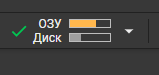


Для предотвращения переполнения ОЗУ может помочь библиотека `gc`. Вставьте строчку `gc.collect()` в цикл ваших экспериментов для сбора и удаления временных данных (кеш).

Перед выполнением задания, пожалуйста, запустите ячейку `Подготовка` ниже:

## Подготовка


### Импорт библиотек

In [1]:
 # Импортируем модели keras: Model
from tensorflow.keras.models import Model

 # Импортируем стандартные слои keras
from tensorflow.keras.layers import Input, Conv2DTranspose, concatenate, Activation
from tensorflow.keras.layers import MaxPooling2D, Conv2D, BatchNormalization, UpSampling2D

# Импортируем оптимизатор Adam
from tensorflow.keras.optimizers import Adam

# Импортируем модуль pyplot библиотеки matplotlib для построения графиков
import matplotlib.pyplot as plt

# Импортируем модуль image для работы с изображениями
from tensorflow.keras.preprocessing import image

# Импортируем библиотеку numpy
import numpy as np

# Импортируем методделения выборки
from sklearn.model_selection import train_test_split

# загрузка файлов по HTML ссылке
import gdown

# Для работы с файлами
import os

# Для генерации случайных чисел
import random

import time

# импортируем модель Image для работы с изображениями
from PIL import Image

# очистка ОЗУ
import gc

### Загрузка датасета

грузим и распаковываем архив картинок

In [2]:
# Загрузка датасета из облака

gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip', None, quiet=False)
#gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_512x384.zip', None, quiet=False)

!unzip -qo 'construction_256x192.zip' # распоковываем архив

Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip
To: /content/construction_256x192.zip
100%|██████████| 214M/214M [00:10<00:00, 20.4MB/s]


## Решение

In [3]:
NUM_CLASSES = 7

IMG_WIDTH = 192
IMG_HEIGHT = 256

TRAIN_DIRECTORY = 'train'
VAL_DIRECTORY = 'val'

CLASS_MAP = {
    0: 0,   # FLOOR
    1: 1,   # CEILING
    2: 2,   # WALL
    3: 3,   # APERTURE
    4: 3,   # DOOR
    5: 3,   # WINDOW
    6: 4,   # COLUMN
    7: 4,   # RAILINGS
    8: 4,   # LADDER
    9: 5,   # INVENTORY
    10: 6,  # LAMP
    11: 6,  # WIRE
    12: 6,  # BEAM
    13: 6,  # EXTERNAL
    14: 6,  # BATTERY
    15: 6   # PEOPLE
}


In [4]:
train_images = []
val_images = []

for filename in sorted(os.listdir(TRAIN_DIRECTORY + '/original')):
    train_images.append(
        image.load_img(
            os.path.join(TRAIN_DIRECTORY + '/original', filename),
            target_size=(IMG_WIDTH, IMG_HEIGHT)
        )
    )

print('Обучающие изображения загружены:', len(train_images))

for filename in sorted(os.listdir(VAL_DIRECTORY + '/original')):
    val_images.append(
        image.load_img(
            os.path.join(VAL_DIRECTORY + '/original', filename),
            target_size=(IMG_WIDTH, IMG_HEIGHT)
        )
    )

print('Проверочные изображения загружены:', len(val_images))


Обучающие изображения загружены: 1900
Проверочные изображения загружены: 100


In [5]:
train_segments = []
val_segments = []

for filename in sorted(os.listdir(TRAIN_DIRECTORY + '/segment')):
    train_segments.append(
        image.load_img(
            os.path.join(TRAIN_DIRECTORY + '/segment', filename),
            target_size=(IMG_WIDTH, IMG_HEIGHT)
        )
    )

print('Обучающие маски загружены:', len(train_segments))

for filename in sorted(os.listdir(VAL_DIRECTORY + '/segment')):
    val_segments.append(
        image.load_img(
            os.path.join(VAL_DIRECTORY + '/segment', filename),
            target_size=(IMG_WIDTH, IMG_HEIGHT)
        )
    )

print('Проверочные маски загружены:', len(val_segments))


Обучающие маски загружены: 1900
Проверочные маски загружены: 100


In [6]:
def images_to_array(images):
    x = np.array([np.array(img) for img in images], dtype=np.float32)
    return x / 255.0


def segments_to_sparse_masks_7_classes(segments, class_map):
    masks = []

    for seg in segments:
        seg = np.array(seg)

        if len(seg.shape) == 3:
            seg = seg[:, :, 0]

        if seg.max() > 15:
            seg = np.round(seg / 255 * 15).astype(np.uint8)

        new_mask = np.zeros_like(seg, dtype=np.uint8)

        for old_class, new_class in class_map.items():
            new_mask[seg == old_class] = new_class

        masks.append(new_mask)

    return np.array(masks, dtype=np.uint8)


x_train = images_to_array(train_images)
x_val = images_to_array(val_images)

y_train = segments_to_sparse_masks_7_classes(
    train_segments,
    CLASS_MAP
)

y_val = segments_to_sparse_masks_7_classes(
    val_segments,
    CLASS_MAP
)

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_val:", x_val.shape)
print("y_val:", y_val.shape)

gc.collect()

x_train: (1900, 192, 256, 3)
y_train: (1900, 192, 256)
x_val: (100, 192, 256, 3)
y_val: (100, 192, 256)


30

In [12]:

# PSPNet

from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout

def conv_bn_relu(x, filters, kernel_size=3):
    x = Conv2D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x


def pyramid_pooling_module(x, bin_sizes=[1, 2, 4, 8]):
    h = x.shape[1]
    w = x.shape[2]

    concat_list = [x]

    for bin_size in bin_sizes:
        pool_h = h // bin_size
        pool_w = w // bin_size

        pooled = AveragePooling2D(
            pool_size=(pool_h, pool_w),
            strides=(pool_h, pool_w),
            padding='same'
        )(x)

        pooled = Conv2D(16, 1, padding='same')(pooled)
        pooled = BatchNormalization()(pooled)
        pooled = Activation('relu')(pooled)

        pooled = UpSampling2D(
            size=(pool_h, pool_w),
            interpolation='bilinear'
        )(pooled)

        concat_list.append(pooled)

    return concatenate(concat_list)


def PSPNet(input_shape=(256, 192, 3), num_classes=7):
    inputs = Input(input_shape)

    # Encoder
    x = conv_bn_relu(inputs, 32)
    x = conv_bn_relu(x, 32)
    x = MaxPooling2D((2, 2))(x)

    x = conv_bn_relu(x, 64)
    x = conv_bn_relu(x, 64)
    x = MaxPooling2D((2, 2))(x)

    x = conv_bn_relu(x, 128)
    x = conv_bn_relu(x, 128)
    x = MaxPooling2D((2, 2))(x)

    x = conv_bn_relu(x, 256)
    x = conv_bn_relu(x, 256)

    # Pyramid Pooling Module
    x = pyramid_pooling_module(x, bin_sizes=[1, 2, 4, 8])

    # Decoder
    x = conv_bn_relu(x, 256)
    x = Dropout(0.3)(x)

    x = UpSampling2D((2, 2), interpolation='bilinear')(x)
    x = conv_bn_relu(x, 128)

    x = UpSampling2D((2, 2), interpolation='bilinear')(x)
    x = conv_bn_relu(x, 64)

    x = UpSampling2D((2, 2), interpolation='bilinear')(x)
    x = conv_bn_relu(x, 32)

    outputs = Conv2D(num_classes, 1, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model


model = PSPNet(
    input_shape=(IMG_WIDTH, IMG_HEIGHT, 3),
    num_classes=NUM_CLASSES
)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

gc.collect()

0

In [13]:
# =========================
# Обучение
# =========================

BATCH_SIZE = 4
EPOCHS = 15

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS
)

gc.collect()

Epoch 1/15
475/475 ━━━━━━━━━━━━━━━━━━━━ 72s 72ms/step - accuracy: 0.7164 - loss: 1.0345 - val_accuracy: 0.7206 - val_loss: 0.9609
Epoch 2/15
475/475 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - accuracy: 0.7883 - loss: 0.6824 - val_accuracy: 0.7387 - val_loss: 0.7528
Epoch 3/15
475/475 ━━━━━━━━━━━━━━━━━━━━ 30s 64ms/step - accuracy: 0.8025 - loss: 0.5823 - val_accuracy: 0.7097 - val_loss: 0.8093
Epoch 4/15
475/475 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - accuracy: 0.8147 - loss: 0.5234 - val_accuracy: 0.7287 - val_loss: 0.7327
Epoch 5/15
475/475 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - accuracy: 0.8254 - loss: 0.4854 - val_accuracy: 0.7486 - val_loss: 0.6495
Epoch 6/15
475/475 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - accuracy: 0.8351 - loss: 0.4509 - val_accuracy: 0.7521 - val_loss: 0.7012
Epoch 7/15
475/475 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - accuracy: 0.8409 - loss: 0.4325 - val_accuracy: 0.7683 - val_loss: 0.6049
Epoch 8/15
475/475 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - accuracy: 0.8484 - loss: 0.4097 - 

25037

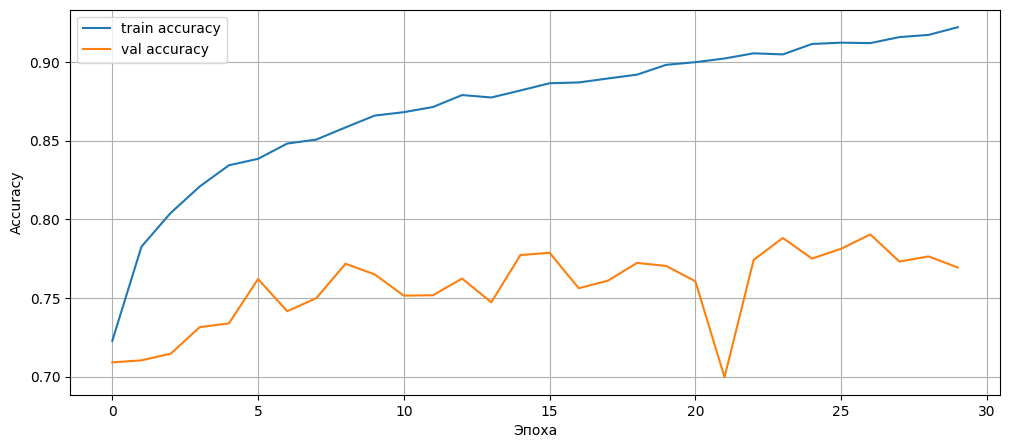

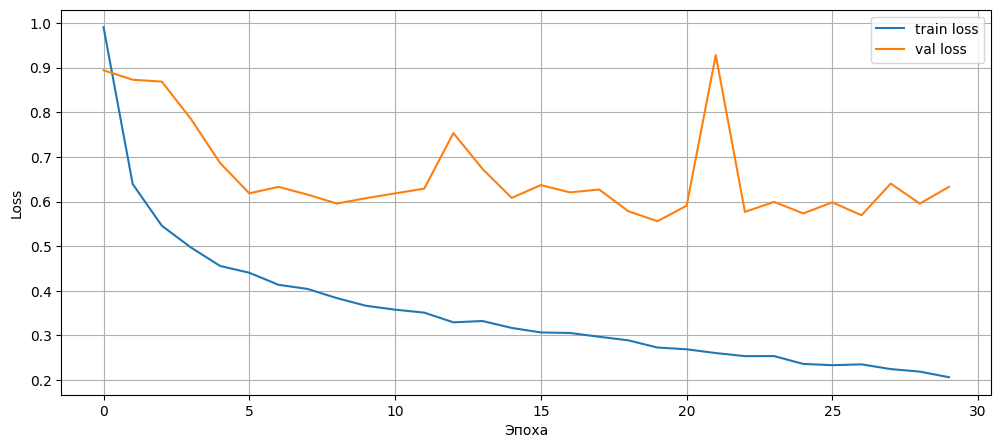

In [9]:

# Графики обучения

plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

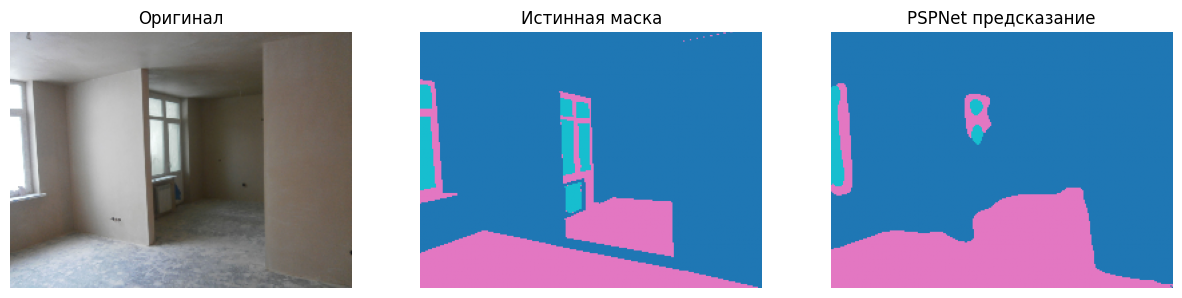

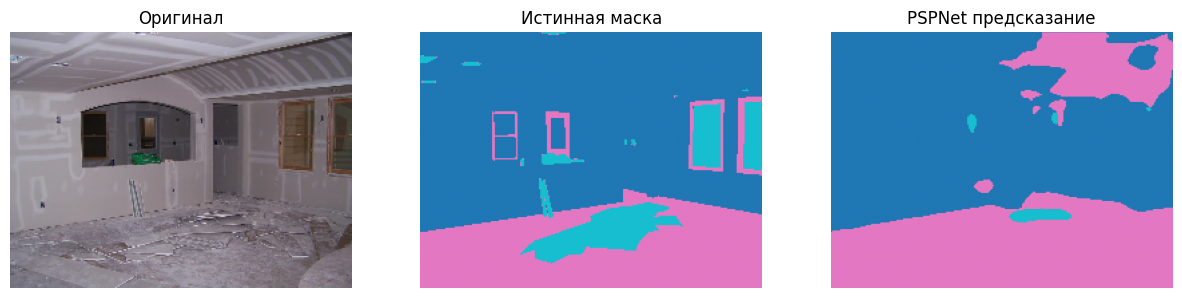

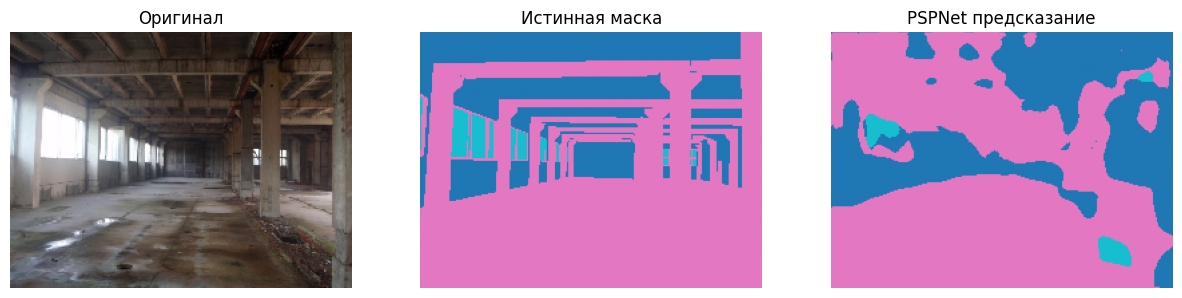

25361

In [11]:
def show_prediction(index):
    img = x_val[index]

    # sparse-маска уже готова, argmax не нужен
    true_mask = y_val[index]

    pred = model.predict(np.expand_dims(img, axis=0), verbose=0)[0]
    pred_mask = np.argmax(pred, axis=-1)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title('Оригинал')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(true_mask, cmap='tab10', vmin=0, vmax=6)
    plt.title('Истинная маска')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask, cmap='tab10', vmin=0, vmax=6)
    plt.title('PSPNet предсказание')
    plt.axis('off')

    plt.show()


show_prediction(0)
show_prediction(1)
show_prediction(2)

gc.collect()